<a href="https://colab.research.google.com/github/conestone/climate-lab/blob/main/GeoSphere_Station_Climate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Climate analysis and change diagnostics from a GeoSphere Austria station**

**Author**: Oliver Konold  
**Date**: August 2026  
**Station Data Source**: GeoSphere Austria (CC BY 4.0), https://data.hub.geosphere.at  
**License of this Collab**: MIT

This notebook fetches a daily weather-station record from **GeoSphere Austria**
(`klima-v2-1d`), derives daily **reference evapotranspiration (ET0)** with the
FAO-56 Penman-Monteith equation, and produces a set of climate-change
diagnostics organised into five sections:

1. **Temperature** — annual trend, warming stripes
2. **Precipitation** — annual totals, monthly seasonality
3. **Evapotranspiration** — annual ET0 trend
4. **Water balance** — climatic water balance P − ET0 by period / by year
5. **Climate indices** — ETCCDI threshold days, precipitation indices, growing-season length

Each section has a short methodological note before the code.

## **1. Setup**

Standard scientific-Python stack plus a `matplotlib` style block for cleaner
plots (no top/right spines, subtle grid, larger bold titles). `%matplotlib inline`
so figures render right in the notebook.

In [ ]:
# @title
%matplotlib inline

import calendar
import os
from datetime import date
from io import StringIO

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Javascript, display

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

# Disable Colab's auto-scroll box for large outputs (e.g. tall multi-subplot
# figures) - registers once, applies to every cell for the rest of the session.
def _resize_colab_cell():
    display(Javascript('google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'))

get_ipython().events.register('pre_run_cell', _resize_colab_cell)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Configuration**

Let's pick a station from the GeoSphere Website: https://dataset.api.hub.geosphere.at/app/frontend/station/historical/klima-v2-1d

**To do a meaningful climate analysis, it's important that the station data cover at least the most recent 30 years climate normal period. So check if data are available from 1991 - 2020.**

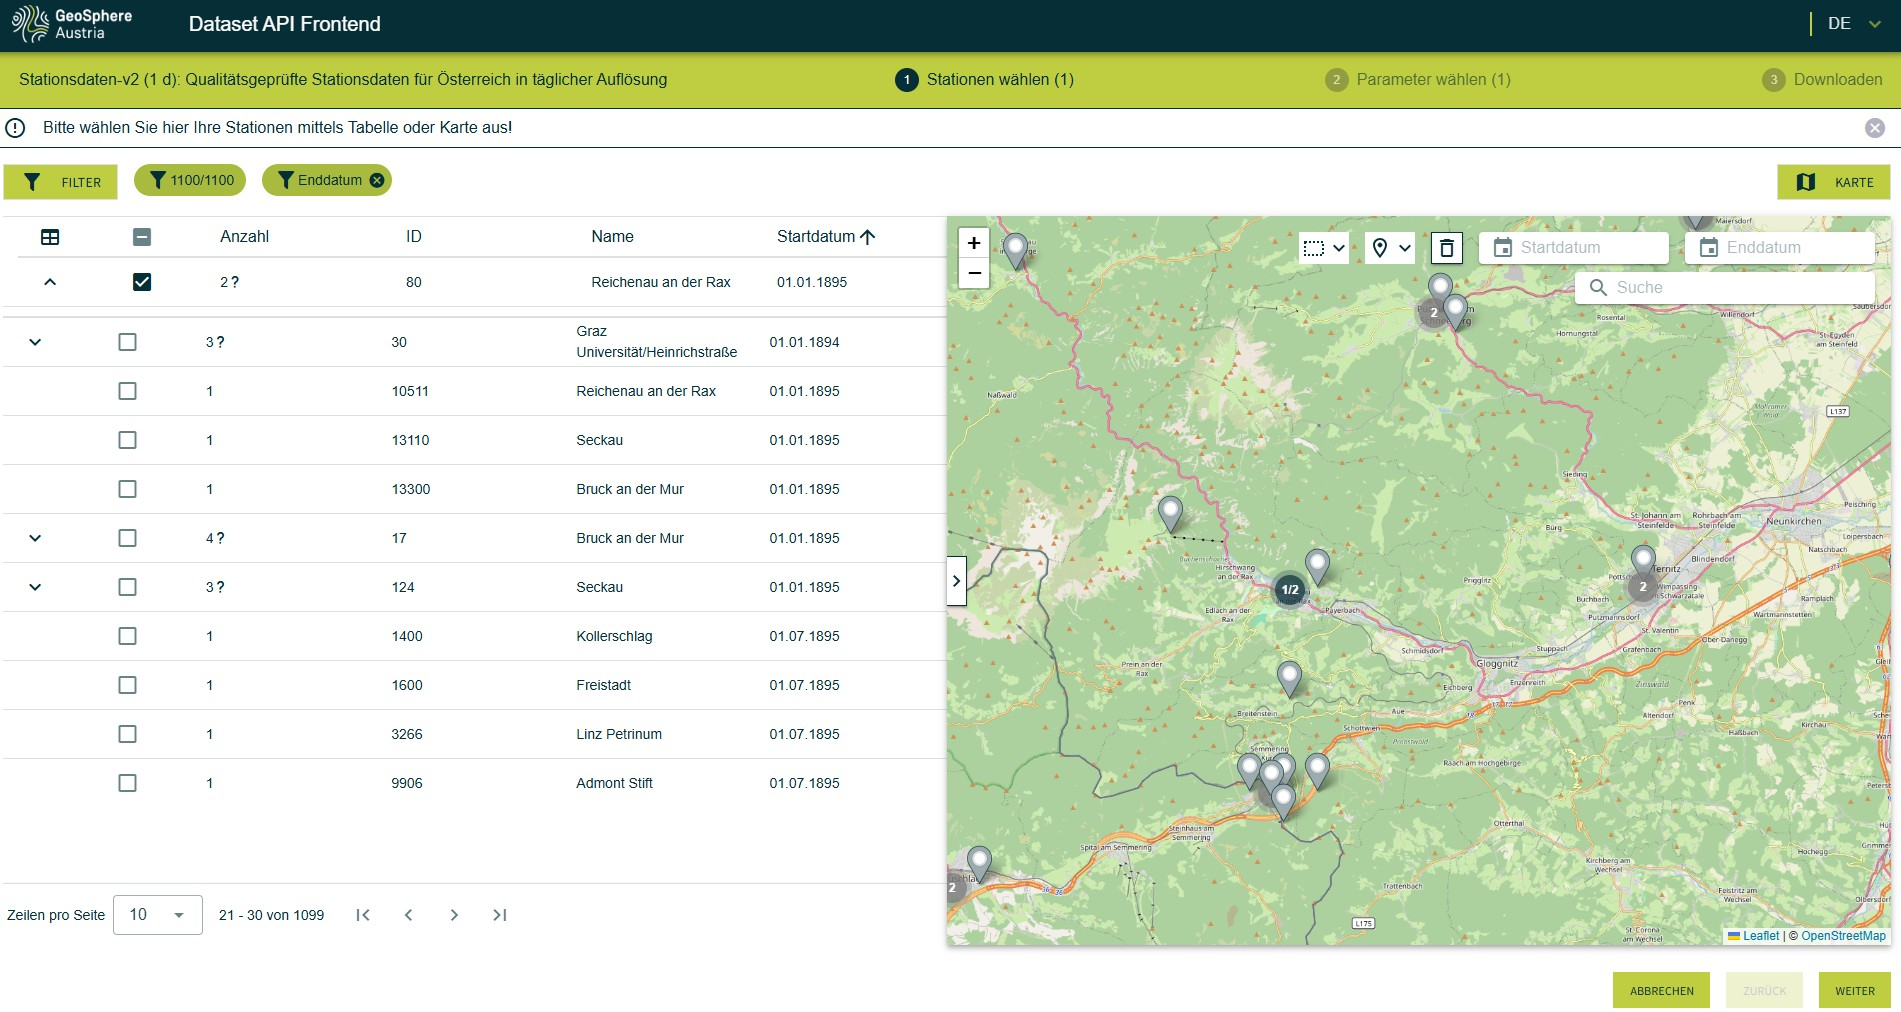

Define Configuration Parameters for the Analysis:

- **station_id** — GeoSphere station code
- **start_date / end_date** — request window (data are always trimmed to the station's actual availability window afterwards; `end_date` defaults to today so the current year is included)
- **parameters** — mapping of human-readable names to GeoSphere codes. Temperature and precipitation are used everywhere; the other six are the additional inputs the FAO-56 Penman-Monteith equation needs
- **reference_period** — the WMO 1981–2010 climatology used as the baseline for anomalies
- **comparison_periods / comparison_years** — used later in the water-balance and seasonality plots

In [ ]:
station_id = "185"           # e.g. Reichenau an der Rax
start_date = "1900-01-01"   # let at 1900-01-01, this covers usually the whole station period
end_date = date.today().isoformat()

base_url = "https://dataset.api.hub.geosphere.at/v1/station/historical/klima-v2-1d"

parameters = {
    "Temperature":     "tl_mittel",
    "Precipitation":   "rr",
    # additional inputs needed for FAO-56 Penman-Monteith ET0:
    "TemperatureMax":  "tlmax",
    "TemperatureMin":  "tlmin",
    "VaporPressure":   "dampf_mittel",   # actual vapor pressure, hPa
    "Pressure":        "p_mittel",       # air pressure, hPa
    "GlobalRadiation": "cglo_j",         # measured solar radiation, J/cm^2
    "WindSpeed":       "vv_mittel",      # mean wind speed, m/s
}

# height above ground at which wind speed is measured (m) - GeoSphere
# synoptic stations are typically 10 m; used to convert to the standard 2 m
wind_measurement_height_m = 10.0

reference_period = (1981, 2010)

comparison_periods = {
    "1961-1990": (1961, 1990),
    "1981-2010": (1981, 2010),
    "1991-2020": (1991, 2020),
}

comparison_years = [2003, 2025, 2026]

# Output layout: one topic folder per subject, all directly under climate_output/
output_dir = "climate_output"
plot_subdirs = {
    "temperature":        os.path.join(output_dir, "temperature"),
    "precipitation":      os.path.join(output_dir, "precipitation"),
    "evapotranspiration": os.path.join(output_dir, "evapotranspiration"),
    "water_balance":      os.path.join(output_dir, "water_balance"),
    "climate_indices":    os.path.join(output_dir, "climate_indices"),
}

for d in plot_subdirs.values():
    os.makedirs(d, exist_ok=True)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **2. Data acquisition**

### **2.1 Station metadata**

One HTTP call to the metadata endpoint returns latitude, altitude and the actual
data availability period for the station. Two guards fire **before** the bulk
download:

- **Freshness**: if the last data point is before the current calendar year, the
  station is decommissioned — bail out.
- **Length**: if the record starts after 1995 there are fewer than 30 years
  available, which is too short for meaningful climate-change trends — bail out.

In [ ]:
# @title
GREEN_BOLD = "\033[1;92m"
RED_BOLD = "\033[1;91m"
RESET = "\033[0m"

def get_station_info(station_id):
    meta = requests.get(f"{base_url}/metadata", timeout=30).json()
    field_pairs = [("valid_from", "valid_to"), ("start", "end"),
                   ("start_time", "end_time"), ("from", "to")]

    for s in meta["stations"]:
        if str(s["id"]) != str(station_id):
            continue
        for start_field, end_field in field_pairs:
            if start_field in s and end_field in s:
                start = pd.Timestamp(s[start_field])
                end = pd.Timestamp(s[end_field])
                if start.tzinfo is not None:
                    start = start.tz_localize(None)
                if end.tzinfo is not None:
                    end = end.tz_localize(None)
                return {"latitude": float(s["lat"]),
                        "altitude": float(s["altitude"]),
                        "start": start, "end": end}
        raise ValueError(
            f"Station id {station_id!r} found, but no recognizable start/end "
            f"field in its metadata entry: {sorted(s.keys())}"
        )
    raise ValueError(f"Station id {station_id!r} not found in metadata from {base_url}")


try:
    info = get_station_info(station_id)

    current_year = pd.Timestamp(end_date).year
    if info["end"].year < current_year:
        raise ValueError(f"Station {station_id!r} is not up-to-date (last point {info['end'].date()}).")

    min_start_year = 1995
    if info["start"].year > min_start_year:
        raise ValueError(f"Station {station_id!r} record too short (starts {info['start'].date()}).")

    print(f"{GREEN_BOLD}Station data cover a climate normal period!")
    print(f"{GREEN_BOLD}Station {station_id}: lat={info['latitude']:.3f}  alt={info['altitude']:.0f} m{RESET}")
    print(f"{GREEN_BOLD}Data availability: {info['start'].date()} -> {info['end'].date()}{RESET}")

except Exception as e:
    print(f"{RED_BOLD}ERROR: {e}{RESET}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Station data cover a climate normal period!
Station 185: lat=46.917  alt=1383 m
Data availability: 1938-01-01 -> 2100-12-31


### **2.2 Daily download and sanity check**

The API is queried once for the intersection of the requested window and the
station's availability window. Two small clean-ups follow:

- Trim leading/trailing rows where **temperature *and* precipitation** are
  missing (secondary sensors like radiation / wind often start decades later
  and we don't want to throw those decades away).
- Replace GeoSphere's `-1` "no precipitation" sentinel with a real `0.0` mm.

Then a per-column / per-year **sanity check**: if a year has more than 5 NaN
days for a variable, the entire year for that variable is set to NaN so it
drops out of every downstream aggregation. Columns are checked independently:
a broken wind sensor doesn't invalidate temperature.

In [ ]:
# @title
def download_station_data(station_id, parameters, start_date, end_date,
                          station_start, station_end):
    request_start = max(pd.Timestamp(start_date), station_start)
    request_end   = min(pd.Timestamp(end_date),   station_end)

    query = {
        "parameters":    ",".join(parameters.values()),
        "station_ids":   station_id,
        "start":         request_start.strftime("%Y-%m-%d"),
        "end":           request_end.strftime("%Y-%m-%d"),
        "output_format": "csv",
    }
    response = requests.get(base_url, params=query, timeout=60)
    response.raise_for_status()

    df = pd.read_csv(StringIO(response.text))
    time_col = [c for c in df.columns if "time" in c.lower() or "date" in c.lower()][0]
    df = df.rename(columns={time_col: "date"})
    df["date"] = pd.to_datetime(df["date"])

    code_to_name = {code: name for name, code in parameters.items()}
    df = df.rename(columns=code_to_name)
    df = df[["date"] + list(parameters.keys())].set_index("date")

    core_cols = [c for c in ("Temperature", "Precipitation") if c in df.columns]
    valid_mask = df[core_cols].notna().all(axis=1)
    if valid_mask.any():
        first = df.index[valid_mask.argmax()]
        last  = df.index[len(valid_mask) - 1 - valid_mask.values[::-1].argmax()]
        df = df.loc[first:last]

    n_no_precip = (df["Precipitation"] == -1).sum()
    if n_no_precip:
        df["Precipitation"] = df["Precipitation"].replace(-1, 0.0)

    return df


def sanity_check_yearly_coverage(df, max_nans_per_year=5):
    df = df.copy()
    year_idx = df.index.year
    for col in df.columns:
        nan_per_year = df[col].isna().groupby(year_idx).sum()
        bad_years = nan_per_year[nan_per_year > max_nans_per_year].index
        if len(bad_years):
            df.loc[year_idx.isin(bad_years), col] = np.nan
    return df


df = download_station_data(station_id, parameters, start_date, end_date,
                           info["start"], info["end"])
df = sanity_check_yearly_coverage(df)
print(f"Downloaded {len(df):,} daily rows, {df.index.min().date()} → {df.index.max().date()}")
# df.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 32,358 daily rows, 1938-01-01 → 2026-08-04


## **3. Reference evapotranspiration (FAO-56 Penman-Monteith)**

**Reference evapotranspiration (ET0)** is the evaporative demand for a hypothetical,
well-watered reference surface — a short grass canopy 0.12 m tall, albedo 0.23,
surface resistance 70 s/m. It depends only on **atmospheric drivers** (net
radiation, temperature, humidity, wind), not on the actual vegetation or soil
moisture at the station. This is what makes it the right quantity to compare across
periods and to attribute changes to climate rather than land-use.

The full **FAO-56 Penman-Monteith equation** (Allen et al. 1998, eq. 6):

$$
\text{ET}_0 \;=\; \frac{0.408\,\Delta\,(R_n - G) \;+\; \gamma\,\dfrac{900}{T + 273}\,u_2\,(e_s - e_a)}
{\Delta \;+\; \gamma\,(1 + 0.34\,u_2)}
$$

with slope of the saturation-vapor-pressure curve $\Delta$, psychrometric constant $\gamma$,
2-m wind $u_2$, mean daily saturation $e_s$ vs. actual vapor pressure $e_a$, net
radiation $R_n$ from measured solar radiation plus an FAO-56 net-longwave
approximation, and soil heat flux $G \approx 0$ at the daily step.

ET0 is **not** the same as PET for the actual vegetation — that would use a
crop coefficient $K_c \cdot \text{ET}_0$.

In [ ]:
# @title
GSC = 0.0820                # solar constant (MJ/m^2/min)
STEFAN_BOLTZMANN = 4.903e-9 # (MJ/K^4/m^2/day)
ALBEDO = 0.23               # reference-crop albedo


def _extraterrestrial_radiation(latitude_deg, day_of_year):
    # Extraterrestrial radiation Ra (MJ/m^2/day), FAO-56 eq. 21.
    phi = np.radians(latitude_deg)
    dr = 1 + 0.033 * np.cos(2 * np.pi * day_of_year / 365)
    solar_declination = 0.409 * np.sin(2 * np.pi * day_of_year / 365 - 1.39)
    sunset_hour_angle = np.arccos(
        np.clip(-np.tan(phi) * np.tan(solar_declination), -1, 1)
    )
    return (24 * 60 / np.pi) * GSC * dr * (
        sunset_hour_angle * np.sin(phi) * np.sin(solar_declination)
        + np.cos(phi) * np.cos(solar_declination) * np.sin(sunset_hour_angle)
    )


def _wind_speed_at_2m(wind_speed, measurement_height_m):
    # FAO-56 eq. 47: log-law adjustment to the standard 2 m height.
    if measurement_height_m == 2.0:
        return wind_speed
    return wind_speed * 4.87 / np.log(67.8 * measurement_height_m - 5.42)


def penman_monteith_et0(df, latitude_deg, elevation_m, wind_measurement_height_m=10.0):
    tmean = df["Temperature"]
    tmax  = df["TemperatureMax"]
    tmin  = df["TemperatureMin"]
    ea       = df["VaporPressure"]  * 0.1     # hPa -> kPa
    pressure = df["Pressure"]       * 0.1     # hPa -> kPa
    rs       = df["GlobalRadiation"] * 0.01   # J/cm^2 -> MJ/m^2/day
    wind = _wind_speed_at_2m(df["WindSpeed"], wind_measurement_height_m)
    day_of_year = df.index.dayofyear.values

    delta = (4098 * (0.6108 * np.exp(17.27 * tmean / (tmean + 237.3)))
             / (tmean + 237.3) ** 2)
    gamma = 0.000665 * pressure

    e_tmax = 0.6108 * np.exp(17.27 * tmax / (tmax + 237.3))
    e_tmin = 0.6108 * np.exp(17.27 * tmin / (tmin + 237.3))
    es = (e_tmax + e_tmin) / 2

    ra  = _extraterrestrial_radiation(latitude_deg, day_of_year)
    rso = (0.75 + 2e-5 * elevation_m) * ra
    rns = (1 - ALBEDO) * rs
    # FAO-56 §R.3: cloudiness function loses accuracy below Rs/Rso ~ 0.33
    rs_rso = np.clip(rs / rso, 0.33, 1.0)
    rnl = (STEFAN_BOLTZMANN * ((tmax + 273.16) ** 4 + (tmin + 273.16) ** 4) / 2
           * (0.34 - 0.14 * np.sqrt(ea))
           * (1.35 * rs_rso - 0.35))
    rn  = rns - rnl
    G   = 0.0  # ~0 at daily step

    numerator   = 0.408 * delta * (rn - G) + gamma * (900 / (tmean + 273)) * wind * (es - ea)
    denominator = delta + gamma * (1 + 0.34 * wind)
    return (numerator / denominator).clip(lower=0).rename("ET0_mm")


df["ET0_mm"] = penman_monteith_et0(
    df, info["latitude"], info["altitude"],
    wind_measurement_height_m=wind_measurement_height_m,
)
# df[["Temperature", "Precipitation", "ET0_mm"]].describe().round(2)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **4. Monthly aggregation**

Daily → monthly:

- **Temperature** → monthly mean
- **Precipitation** → monthly sum
- **ET0** → monthly sum (evaporation is a flux; the meaningful monthly aggregate is a total)

Two safeguards keep the monthly series honest:

- `min_count=1` on the sums: a month with **no** observations becomes NaN instead of a silent 0.
- `_drop_unfinished_months`: any month whose last day is in the future is removed. Example — on 2026-08-04 August 2026 is dropped, because only 4 of its 31 days exist yet.

In [ ]:
# @title
reference_year = 2001
month_names = list(calendar.month_abbr)[1:]


def _drop_unfinished_months(monthly, reference_date=None):
    if reference_date is None:
        reference_date = pd.Timestamp.today().normalize()
    is_finished = (
        (monthly.index.year < reference_date.year)
        | ((monthly.index.year == reference_date.year)
           & (monthly.index.month < reference_date.month))
    )
    return monthly[is_finished]


def compute_monthly_timeseries(df):
    monthly = pd.DataFrame({
        "Temperature":   df["Temperature"].resample("MS").mean(),
        "Precipitation": df["Precipitation"].resample("MS").sum(min_count=1),
        "ET0_mm":        df["ET0_mm"].resample("MS").sum(min_count=1),
    })
    monthly["water_balance_mm"] = monthly["Precipitation"] - monthly["ET0_mm"]
    return _drop_unfinished_months(monthly)


def compute_et0_climatology(monthly, reference_period):
    ref_start, ref_end = reference_period
    ref_data = monthly[(monthly.index.year >= ref_start) & (monthly.index.year <= ref_end)]
    grouped = ref_data.groupby(ref_data.index.month).mean().reindex(range(1, 13))
    return pd.DataFrame({
        "month":                 month_names,
        "mean_temperature_degC": grouped["Temperature"].values,
        "mean_precipitation_mm": grouped["Precipitation"].values,
        "mean_ET0_mm":           grouped["ET0_mm"].values,
        "mean_water_balance_mm": grouped["water_balance_mm"].values,
    })


monthly     = compute_monthly_timeseries(df)
climatology = compute_et0_climatology(monthly, reference_period)
# climatology.round(1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **5. Temperature**

### **5.1 Annual mean + linear trend**

We plot the daily series as a soft background, overlay the **annual mean**
(only fully-covered years contribute) and fit a **linear trend through the
annual means** — less noisy than fitting on daily values, and directly
interpretable in °C/decade.

An in-progress year (e.g. the current year) still shows in the daily line
but is excluded from both the annual points and the trend, so a January-only
2026 doesn't drag the trend down.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

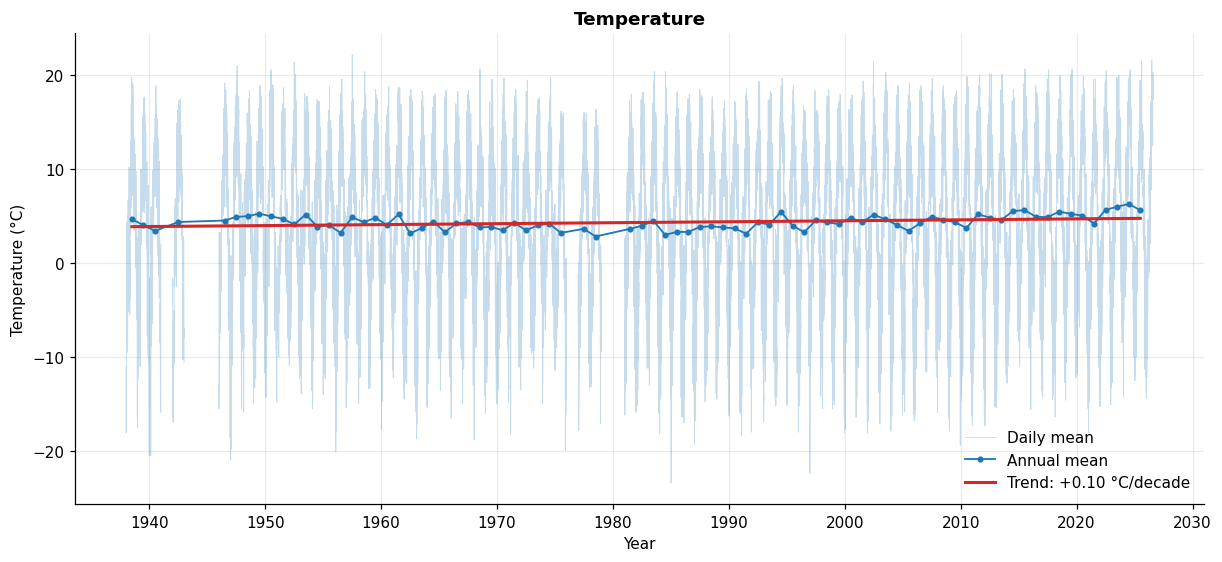

In [ ]:
# @title
def get_complete_years(df):
    counts = df.groupby(df.index.year).size()
    expected = counts.index.map(lambda y: 366 if calendar.isleap(y) else 365)
    return counts[counts >= expected].index


def plot_temperature(df, save_path=None):
    complete_years = get_complete_years(df)
    annual = df["Temperature"].groupby(df.index.year).mean().dropna()
    annual = annual[annual.index.isin(complete_years)]
    annual_dates = pd.to_datetime(annual.index.astype(str) + "-07-01")

    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    ax.plot(df.index, df["Temperature"], color="tab:blue", alpha=0.25,
            linewidth=0.6, label="Daily mean")
    if not annual.empty:
        ax.plot(annual_dates, annual.values, color="tab:blue", marker="o",
                markersize=3, linewidth=1.2, label="Annual mean")
    if len(annual) >= 2:
        slope, intercept = np.polyfit(annual.index.values.astype(float), annual.values, 1)
        trend = slope * annual.index.values + intercept
        ax.plot(annual_dates, trend, color="tab:red", linewidth=2,
                label=f"Trend: {slope * 10:+.2f} °C/decade")

    ax.set_xlabel("Year")
    ax.set_ylabel("Temperature (°C)")
    ax.set_title("Temperature")
    ax.legend()
    if save_path:
        fig.savefig(save_path)

plot_temperature(df, os.path.join(plot_subdirs["temperature"], "temperature.png"))

### **5.2 Warming stripes**

The Ed Hawkins (2018) style: one vertical stripe per year, colored by its
**annual mean-T anomaly** relative to the reference period. Red = warmer than
reference, blue = cooler. No axes needed on the y — the chart is meant to
carry the trend visually, with time on x and warmth on the color scale.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

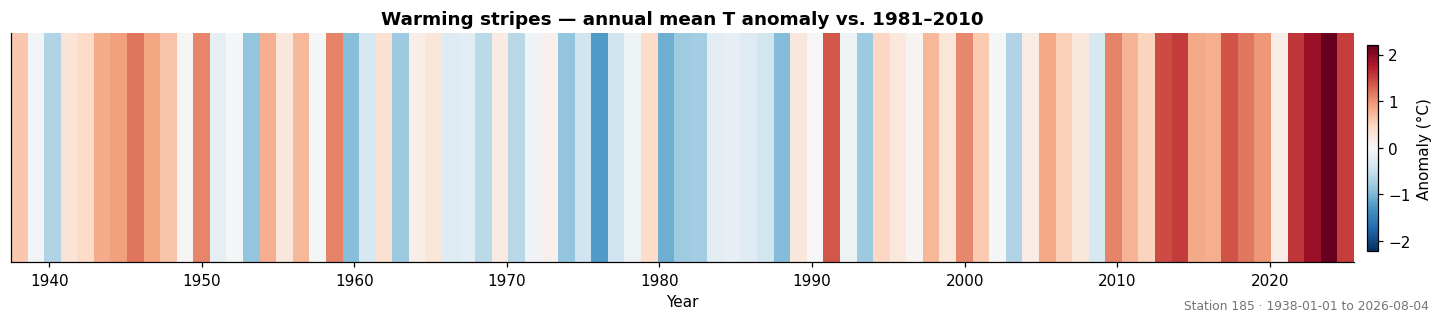

In [ ]:
# @title
def _station_footer(fig, df):
    fig.text(0.995, 0.005,
             f"Station {station_id} · {df.index.min().date()} to {df.index.max().date()}",
             ha="right", va="bottom", fontsize=8, alpha=0.55)


def _valid_years_mask(series, min_valid=360):
    return series.notna().groupby(series.index.year).sum() >= min_valid


def _annual_mean(series, min_valid=360):
    ann = series.groupby(series.index.year).mean()
    mask = _valid_years_mask(series, min_valid)
    return ann.where(mask.reindex(ann.index, fill_value=False)).dropna()


def _annual_count(condition, valid_series, min_valid=360):
    yr = condition.index.year
    counts = (condition & valid_series.notna()).groupby(yr).sum().astype(float)
    mask = _valid_years_mask(valid_series, min_valid)
    return counts.where(mask.reindex(counts.index, fill_value=False)).dropna()


def _add_trend(ax, x, y, unit="", loc="upper left"):
    if len(x) < 2:
        return
    slope, intercept = np.polyfit(x, y, 1)
    per_decade = slope * 10
    fmt = "+.0f" if unit == "days" and abs(per_decade) >= 1 else "+.2f"
    ax.plot(x, slope * np.asarray(x) + intercept,
            color="black", linewidth=1.5,
            label=f"Trend: {per_decade:{fmt}} {unit}/decade")
    ax.legend(loc=loc, fontsize=9)


def plot_warming_stripes(df, reference_period, save_path=None):
    annual = _annual_mean(df["Temperature"])
    if annual.empty:
        return None
    ref_mean = annual.loc[reference_period[0]:reference_period[1]].mean()
    anom = annual - ref_mean

    vlim = float(np.nanmax(np.abs(anom.values))) or 1.0
    fig, ax = plt.subplots(figsize=(13, 2.8), constrained_layout=True)
    im = ax.imshow(anom.values.reshape(1, -1), aspect="auto", cmap="RdBu_r",
                   vmin=-vlim, vmax=vlim,
                   extent=[anom.index.min() - 0.5, anom.index.max() + 0.5, 0, 1])
    ax.set_yticks([])
    ax.set_xlabel("Year")
    ax.set_title(f"Warming stripes — annual mean T anomaly vs. "
                 f"{reference_period[0]}–{reference_period[1]}")
    ax.grid(False)
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.01, shrink=0.9)
    cbar.set_label("Anomaly (°C)")
    _station_footer(fig, df)
    if save_path:
        fig.savefig(save_path)
plot_warming_stripes(df, reference_period,
                     os.path.join(plot_subdirs["temperature"], "warming_stripes.png"))

## **6. Precipitation**

### **6.1 Annual totals + trend**

Bars = annual precipitation sums, red line = linear trend in mm/decade.
Same "only fully-covered years" rule as for temperature — a partial year is
dropped to avoid the trend being pulled down by an artificially low total.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

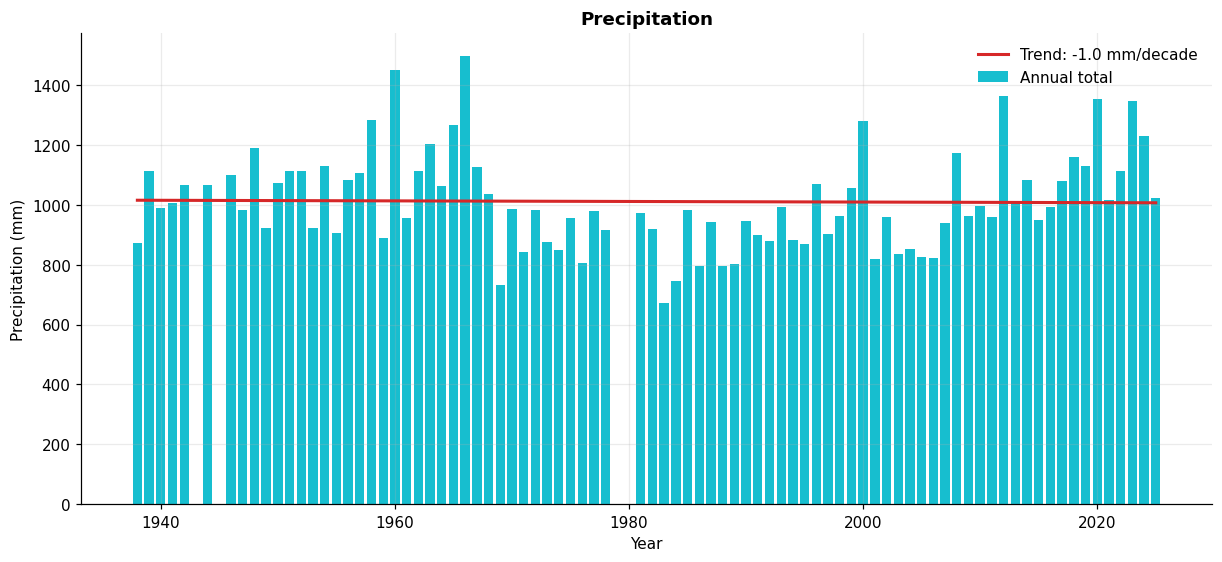

In [ ]:
# @title
def plot_precipitation(df, save_path=None):
    complete_years = get_complete_years(df)
    annual = df["Precipitation"].groupby(df.index.year).sum(min_count=1).dropna()
    annual = annual[annual.index.isin(complete_years)]
    if annual.empty:
        print("[plot_precipitation] no complete year - skipping")
        return None

    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    ax.bar(annual.index, annual.values, color="tab:cyan", label="Annual total")
    if len(annual) >= 2:
        slope, intercept = np.polyfit(annual.index, annual.values, 1)
        trend = slope * annual.index + intercept
        ax.plot(annual.index, trend, color="tab:red", linewidth=2,
                label=f"Trend: {slope * 10:+.1f} mm/decade")
    ax.set_xlabel("Year"); ax.set_ylabel("Precipitation (mm)")
    ax.set_title("Precipitation")
    ax.legend()
    if save_path:
        fig.savefig(save_path)
plot_precipitation(df, os.path.join(plot_subdirs["precipitation"], "precipitation.png"))

### **6.2 Seasonality — periods vs. individual years**

Two side-by-side panels:

- **Left**: monthly-precipitation climatology per `comparison_period` — one line
  per period. Reveals shifts in the *seasonal cycle* (e.g. wetter summers become
  drier, wetter winters shift into spring).
- **Right**: monthly precipitation for the years in `comparison_years` as
  grouped bars, with the most recent period overlaid as a black line for
  context — so you can see how a specific recent year compares to the current
  30-year climatology.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

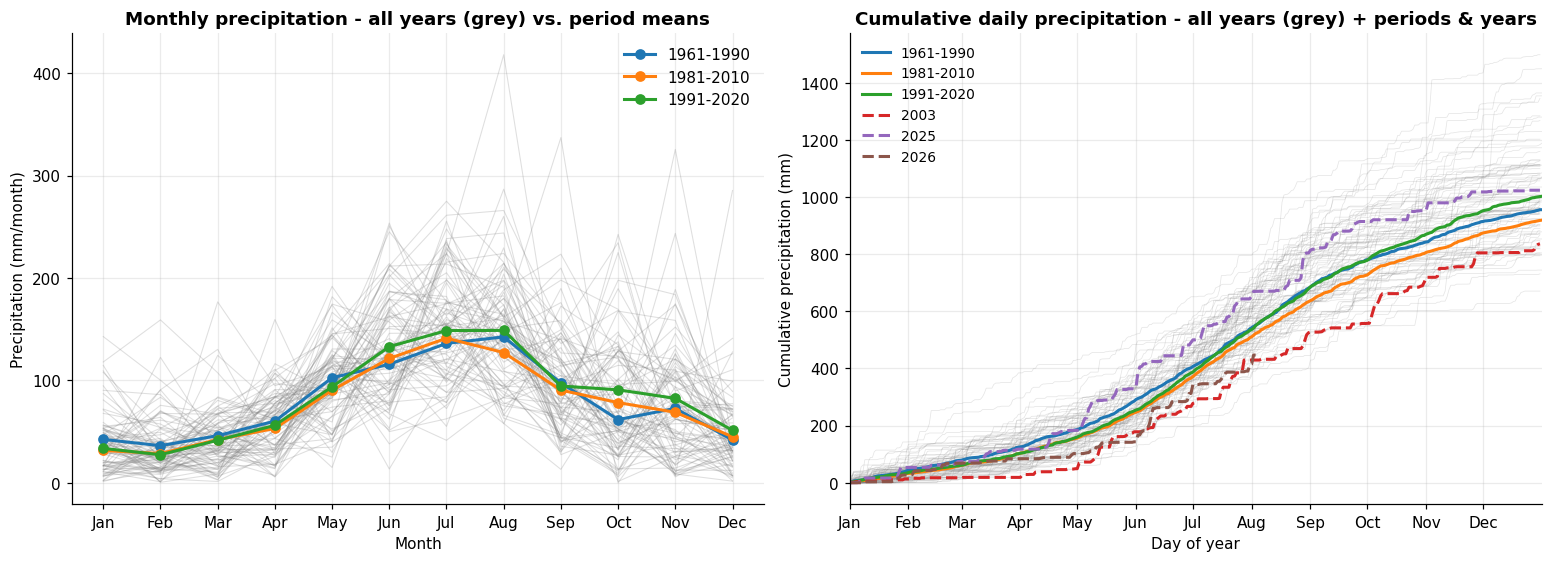

In [ ]:
# @title
def plot_precipitation_seasonality(df, monthly, periods, years, save_path=None):
    """Two side-by-side panels:
      Left  - monthly precipitation. All available years drawn as thin grey
              lines in the background; each comparison period drawn on top as
              a thick colored line (mean across the years in the period).
      Right - cumulative daily precipitation from Jan 1. All years light grey;
              each comparison period thick (mean daily precip in the period,
              cumulated), each comparison year thick (that year's own daily
              cumulative, dashed to distinguish it from period means).
    """
    daily_p = df["Precipitation"]
    data_start, data_end = monthly.index.year.min(), monthly.index.year.max()
    x = np.arange(12)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    # ---- Left: monthly precipitation ----
    all_years = sorted(monthly.index.year.unique())
    for year in all_years:
        yp = monthly.loc[monthly.index.year == year, "Precipitation"]
        yp = yp.set_axis(yp.index.month).reindex(range(1, 13))
        ax1.plot(x, yp.values, color="grey", alpha=0.25, linewidth=0.7)

    for label, (start, end) in periods.items():
        if start < data_start or end > data_end:
            continue
        sub = monthly.loc[
            (monthly.index.year >= start) & (monthly.index.year <= end),
            "Precipitation",
        ]
        monthly_mean = sub.groupby(sub.index.month).mean().reindex(range(1, 13))
        ax1.plot(x, monthly_mean.values, marker="o", linewidth=2.0, label=label)

    ax1.set_xticks(x); ax1.set_xticklabels(month_names)
    ax1.set_xlabel("Month"); ax1.set_ylabel("Precipitation (mm/month)")
    ax1.set_title("Monthly precipitation - all years (grey) vs. period means")
    ax1.legend()

    # ---- Right: cumulative daily precipitation ----
    for year in sorted(daily_p.index.year.unique()):
        y_data = daily_p[daily_p.index.year == year].dropna()
        if len(y_data) < 30:
            continue
        cs = y_data.cumsum()
        doy = y_data.index.dayofyear.values
        ax2.plot(doy, cs.values, color="grey", alpha=0.2, linewidth=0.5)

    # Period lines: mean daily precip by DOY, then cumulated. This is the
    # "average annual cumulative curve" for the period - a more stable
    # summary than averaging per-year cumulatives directly.
    for label, (start, end) in periods.items():
        if start < data_start or end > data_end:
            continue
        period_p = daily_p[(daily_p.index.year >= start) & (daily_p.index.year <= end)]
        mean_daily = period_p.groupby(period_p.index.dayofyear).mean()
        mean_daily = mean_daily.reindex(range(1, 367), fill_value=0)
        mean_cum = mean_daily.cumsum()
        ax2.plot(mean_cum.index, mean_cum.values, linewidth=2.0, label=label)

    # Comparison years - each drawn as its own thick dashed line
    for year in (years or []):
        y_data = daily_p[daily_p.index.year == year].dropna()
        if len(y_data) < 30:
            continue
        cs = y_data.cumsum()
        doy = y_data.index.dayofyear.values
        ax2.plot(doy, cs.values, linewidth=2.0, linestyle="--", label=str(year))

    month_starts = [pd.Timestamp(2001, m, 1).dayofyear for m in range(1, 13)]
    ax2.set_xticks(month_starts); ax2.set_xticklabels(month_names)
    ax2.set_xlim(1, 366)
    ax2.set_xlabel("Day of year"); ax2.set_ylabel("Cumulative precipitation (mm)")
    ax2.set_title("Cumulative daily precipitation - all years (grey) + periods & years")
    ax2.legend(fontsize=9)

    if save_path:
        fig.savefig(save_path)


plot_precipitation_seasonality(
    df, monthly, comparison_periods, comparison_years,
    save_path=os.path.join(plot_subdirs["precipitation"], "precipitation_seasonality.png"),
)

## **7. Evapotranspiration**

Annual ET0 totals + trend. Since ET0 depends only on **atmospheric drivers**
(net radiation, temperature, humidity, wind), a rising trend directly signals a
higher atmospheric evaporative demand — an important driver of drought stress
independent of precipitation.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

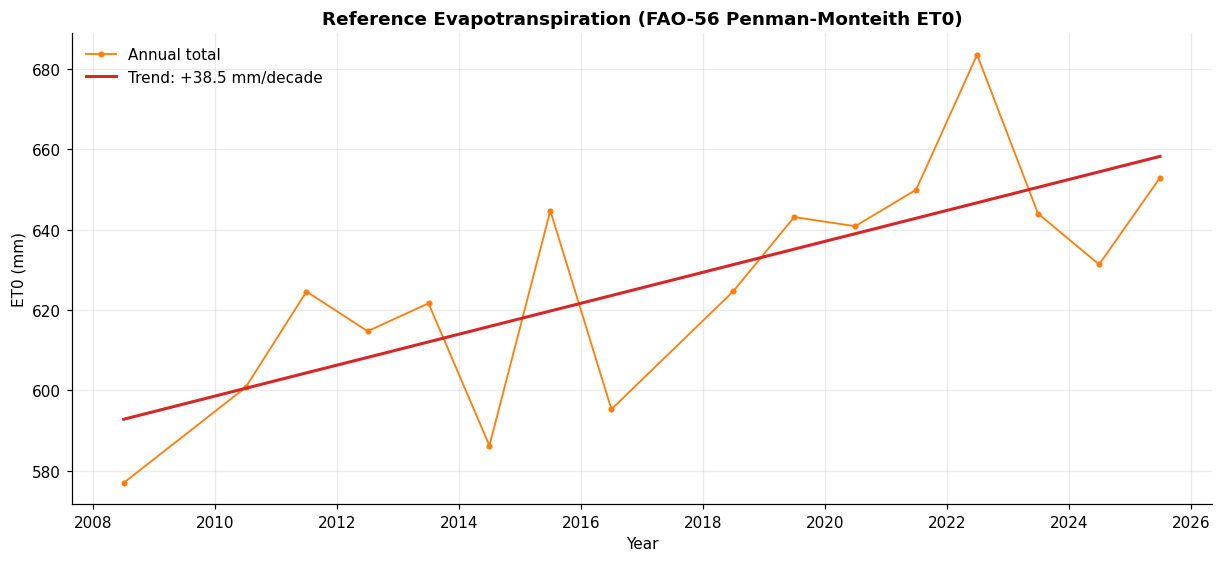

In [ ]:
# @title
def plot_et0(df, save_path=None):
    complete_years = get_complete_years(df)
    annual = df["ET0_mm"].groupby(df.index.year).sum(min_count=1).dropna()
    annual = annual[annual.index.isin(complete_years)]
    if annual.empty:
        print("[plot_et0] no complete year of ET0 - skipping "
              "(station probably lacks radiation/wind/vapor pressure inputs)")
        return None
    annual_dates = pd.to_datetime(annual.index.astype(str) + "-07-01")

    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    ax.plot(annual_dates, annual.values, color="tab:orange", marker="o",
            markersize=3, linewidth=1.2, label="Annual total")
    if len(annual) >= 2:
        slope, intercept = np.polyfit(annual.index.values.astype(float), annual.values, 1)
        trend = slope * annual.index.values + intercept
        ax.plot(annual_dates, trend, color="tab:red", linewidth=2,
                label=f"Trend: {slope * 10:+.1f} mm/decade")
    ax.set_xlabel("Year"); ax.set_ylabel("ET0 (mm)")
    ax.set_title("Reference Evapotranspiration (FAO-56 Penman-Monteith ET0)")
    ax.legend()
    if save_path:
        fig.savefig(save_path)
plot_et0(df, os.path.join(plot_subdirs["evapotranspiration"], "et0.png"))

## **8.  Climatic water balance**

The **climatic water balance** is $P - \text{ET}_0$: precipitation minus
atmospheric evaporative demand.

- $P > \text{ET}_0$ → **surplus**: moisture available for runoff, groundwater recharge, vegetation.
- $P < \text{ET}_0$ → **deficit**: atmospheric demand exceeds rainfall; a well-watered reference surface would be drawing on soil storage.

This is a *climatic* indicator (reference surface, not the actual land cover),
so it isolates the *atmospheric* signal — well-suited for climate-change trend
detection.

### **8.1 Climatic water balance per reference period + per year**

One subplot per available period + one per year in `comparison_years`. All
subplots share the **same y-axis limits**, so surplus and deficit magnitudes
are directly comparable across panels.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

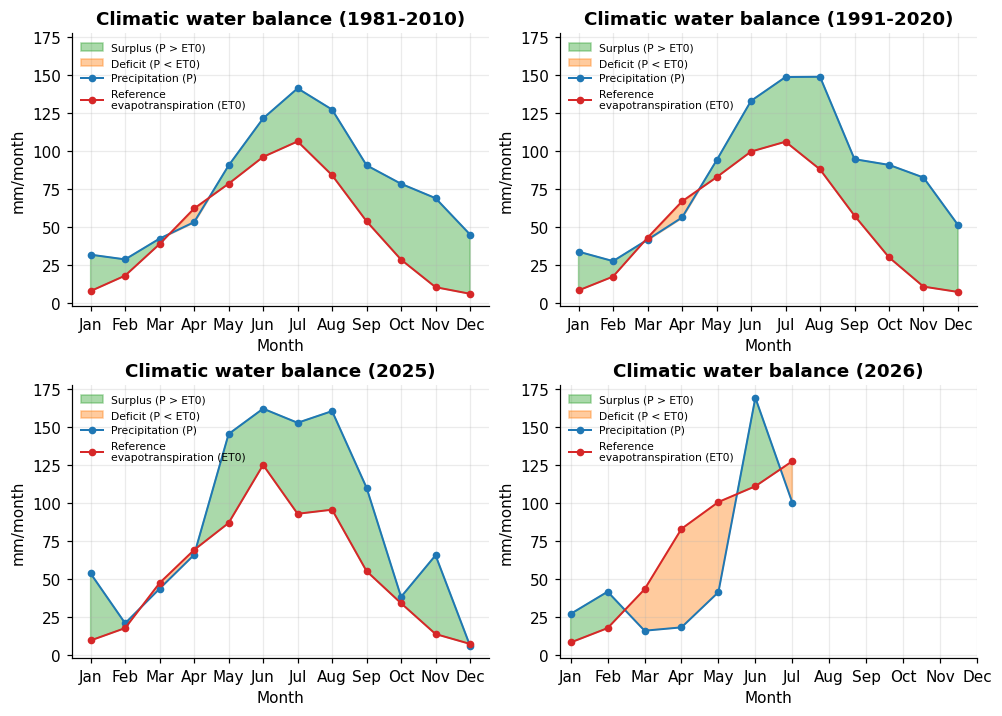

In [ ]:
# @title
def _draw_water_balance(ax, climatology, period_label=None):
    months = climatology["month"].values
    x = np.arange(len(months))
    precip = climatology["mean_precipitation_mm"].values
    et0    = climatology["mean_ET0_mm"].values

    ax.fill_between(x, precip, et0, where=(precip >= et0), interpolate=True,
                    color="tab:green",  alpha=0.4, label="Surplus (P > ET0)")
    ax.fill_between(x, precip, et0, where=(precip <  et0), interpolate=True,
                    color="tab:orange", alpha=0.4, label="Deficit (P < ET0)")
    ax.plot(x, precip, color="tab:blue", marker="o", markersize=4, linewidth=1.3, label="Precipitation (P)")
    ax.plot(x, et0,    color="tab:red",  marker="o", markersize=4, linewidth=1.3,
            label="Reference\nevapotranspiration (ET0)")

    ax.set_xticks(x); ax.set_xticklabels(months)
    ax.set_xlabel("Month"); ax.set_ylabel("mm/month")
    ax.set_title("Climatic water balance" + (f" ({period_label})" if period_label else ""))
    ax.legend(fontsize=7, loc="upper left")


def _is_complete_climatology(climatology):
    """True only if every month has a value for all four variables - used
    to skip a period/year entirely rather than plotting it with a silent
    gap (e.g. a period for which ET0 inputs like radiation/wind simply
    weren't measured yet)."""
    cols = ["mean_temperature_degC", "mean_precipitation_mm",
            "mean_ET0_mm", "mean_water_balance_mm"]
    return climatology[cols].notna().all().all()


def compute_single_year_water_balance(monthly, year):
    data_start, data_end = monthly.index.year.min(), monthly.index.year.max()
    if year < data_start or year > data_end:
        return None
    year_data = monthly[monthly.index.year == year].copy()
    if year_data.empty:
        return None
    if not year_data[["Temperature", "Precipitation", "ET0_mm"]].notna().all().all():
        return None
    year_data = year_data.set_index(year_data.index.month).reindex(range(1, 13))
    return pd.DataFrame({
        "month":                 month_names,
        "mean_temperature_degC": year_data["Temperature"].values,
        "mean_precipitation_mm": year_data["Precipitation"].values,
        "mean_ET0_mm":           year_data["ET0_mm"].values,
        "mean_water_balance_mm": year_data["water_balance_mm"].values,
    })


def compute_water_balance_comparison(monthly, periods, years=None):
    data_start, data_end = monthly.index.year.min(), monthly.index.year.max()
    available = {}
    for label, (start, end) in periods.items():
        if start >= data_start and end <= data_end:
            clim = compute_et0_climatology(monthly, (start, end))
            if _is_complete_climatology(clim):
                available[label] = clim
    for year in years or []:
        year_result = compute_single_year_water_balance(monthly, year)
        if year_result is not None:
            available[str(year)] = year_result
    return available


def plot_water_balance_periods(monthly, periods, years=None, save_path=None):
    entries = compute_water_balance_comparison(monthly, periods, years)
    if not entries:
        return None
    n_cols = 2
    n_rows = -(-len(entries) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows),
                              constrained_layout=True)
    axes = np.atleast_1d(axes).flatten()
    for ax, (label, clim) in zip(axes, entries.items()):
        _draw_water_balance(ax, clim, label)
    for ax in axes[len(entries):]:
        ax.set_visible(False)

    # shared y-axis so surplus/deficit magnitudes are directly comparable
    all_vals = np.concatenate([
        np.concatenate([c["mean_precipitation_mm"].values, c["mean_ET0_mm"].values])
        for c in entries.values()
    ])
    all_vals = all_vals[np.isfinite(all_vals)]
    if all_vals.size:
        lo, hi = float(all_vals.min()), float(all_vals.max())
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        for ax in axes[:len(entries)]:
            ax.set_ylim(min(0, lo - pad), hi + pad)

    if save_path:
        fig.savefig(save_path)

plot_water_balance_periods(
    monthly, comparison_periods, comparison_years,
    save_path=os.path.join(plot_subdirs["water_balance"], "water_balance.png"),
)

### **8.2 Climatic Water Balance overlay (P − ET0)**

One line per period / year, all on the same axes: the **monthly water balance
(P − ET0)** relative to zero. Single-year lines are dashed to distinguish them
from the multi-year climatology lines. Easy to spot which months are drying
vs. wetting over time.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

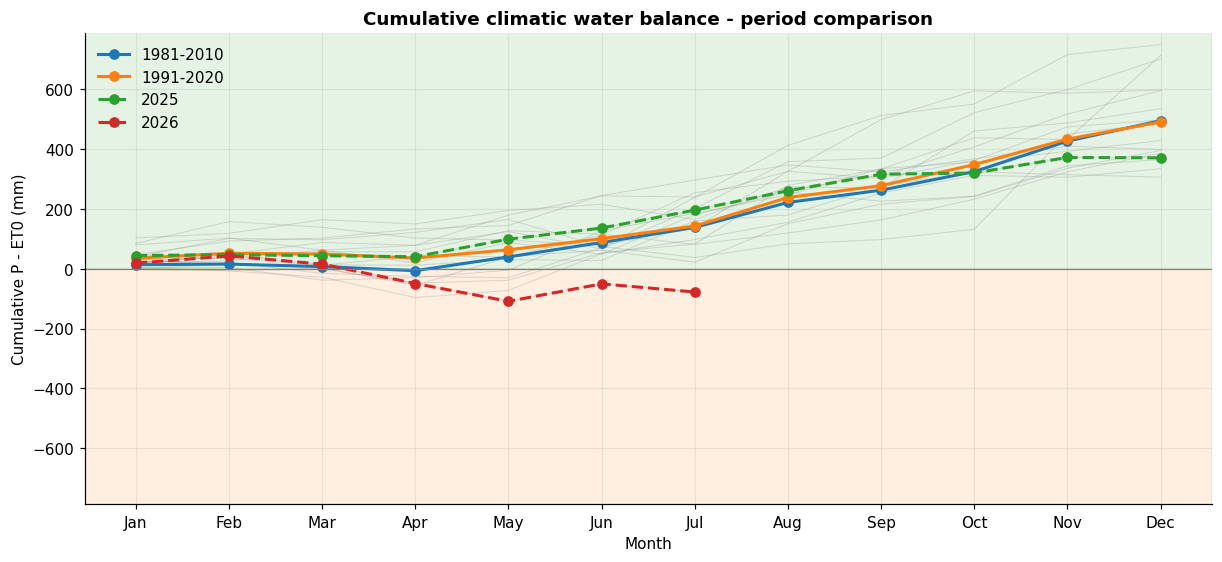

In [ ]:
# @title
def plot_water_balance_comparison(comparison, monthly, save_path=None):
    """Cumulative climatic water balance (P - ET0 summed from January).
    Every year of the record is drawn as a thin grey background line, so the
    period / individual-year curves are visible against the full spread."""
    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    x = np.arange(12)

    # Whole-plot background: green above 0, orange below 0 - drawn first
    # (zorder=0) and behind everything else (lines get the default,
    # higher zorder so they stay on top)
    ax.axhspan(0, 10000, color="tab:green", alpha=0.12, zorder=0)
    ax.axhspan(-10000, 0, color="tab:orange", alpha=0.12, zorder=0)

    # Background: cumulative curve for every year of the record.
    # cumsum() with skipna=True keeps the running total across NaN gaps
    # (NaN positions themselves stay blank), so a partial year draws up to
    # its last valid month.
    background_curves = []
    for year in sorted(monthly.index.year.unique()):
        yd = monthly.loc[monthly.index.year == year, "water_balance_mm"]
        yd = yd.set_axis(yd.index.month).reindex(range(1, 13))
        cum = yd.cumsum().values
        background_curves.append(cum)
        ax.plot(x, cum, color="grey", alpha=0.25, linewidth=0.7)

    # Foreground: comparison periods (solid) and single years (dashed)
    foreground_curves = []
    for label, clim in comparison.items():
        is_single_year = label.isdigit()
        cum = np.cumsum(clim["mean_water_balance_mm"].values)
        foreground_curves.append(cum)
        ax.plot(x, cum, marker="o", linewidth=2.0,
                linestyle="--" if is_single_year else "-", label=label)

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(month_names)
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative P - ET0 (mm)")
    ax.set_title("Cumulative climatic water balance - period comparison")

    # symmetric y-limits, scaled to the largest absolute cumulative value
    # across every curve (background years + foreground comparison lines)
    all_cum = np.concatenate(background_curves + foreground_curves)
    max_abs = np.nanmax(np.abs(all_cum))
    ax.set_ylim(-max_abs * 1.05, max_abs * 1.05)

    ax.legend()
    if save_path:
        fig.savefig(save_path)


comparison = compute_water_balance_comparison(monthly, comparison_periods, comparison_years)
plot_water_balance_comparison(
    comparison, monthly,
    save_path=os.path.join(plot_subdirs["water_balance"], "water_balance_comparison.png"),
)

## **9. Climate indices**

Standard climate-change monitoring indices, mostly from the WMO / **ETCCDI**
(Expert Team on Climate Change Detection and Indices; Karl et al. 1999, Zhang
et al. 2011).

### **9.1 Threshold-day counts**

Five annual counts using daily Tmax / Tmin, following the Austrian GeoSphere /
DWD convention (`≥`/`<` thresholds — ETCCDI uses strict `>`/`<`; the
numerical difference is ≤ 1 day/yr):

| Term (DE)      | English         | Threshold        |
|----------------|-----------------|------------------|
| Frosttag       | Frost day       | Tmin < 0 °C      |
| Eistag         | Ice day         | Tmax < 0 °C      |
| Sommertag      | Summer day      | Tmax ≥ 25 °C     |
| Hitzetag       | Hot day         | Tmax ≥ 30 °C     |
| Tropennacht    | Tropical night  | Tmin ≥ 20 °C     |

<br>

Rising Summer/Hot/Tropical-night trends and falling Frost/Ice trends together
paint an unambiguous warming picture.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

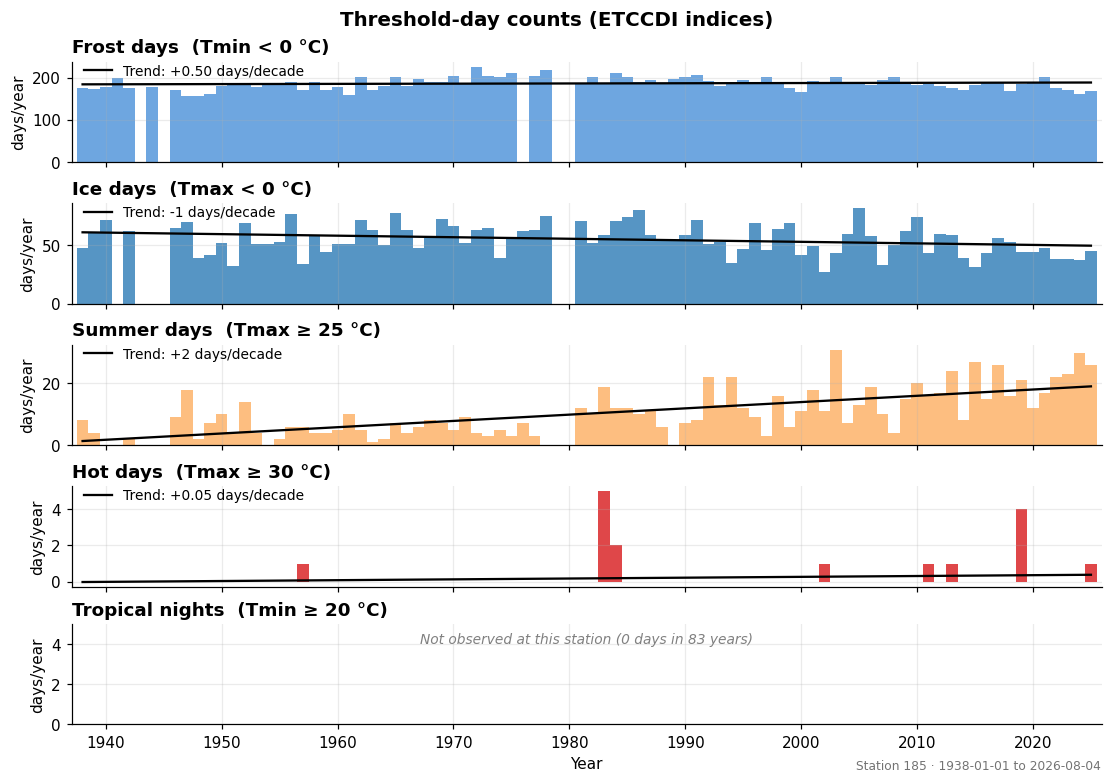

In [ ]:
# @title
def plot_threshold_days(df, save_path=None):
    tmax, tmin = df["TemperatureMax"], df["TemperatureMin"]
    indices = [
        ("Frost days  (Tmin < 0 °C)",       tmin < 0,   tmin, "#4a90d9"),
        ("Ice days  (Tmax < 0 °C)",         tmax < 0,   tmax, "#2c7bb6"),
        ("Summer days  (Tmax ≥ 25 °C)",     tmax >= 25, tmax, "#fdae61"),
        ("Hot days  (Tmax ≥ 30 °C)",        tmax >= 30, tmax, "#d7191c"),
        ("Tropical nights  (Tmin ≥ 20 °C)", tmin >= 20, tmin, "#8856a7"),
    ]
    fig, axes = plt.subplots(5, 1, figsize=(10, 7), sharex=True,
                              constrained_layout=True)
    for ax, (label, cond, src, color) in zip(axes, indices):
        counts = _annual_count(cond, src)
        if counts.empty:
            ax.text(0.5, 0.5, f"{label}: no data",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_yticks([]); continue
        ax.bar(counts.index, counts.values, color=color, alpha=0.8,
               width=1.0, edgecolor="none")
        total = int(counts.sum())
        if total <= 1:
            ax.text(0.5, 0.85,
                    f"Not observed at this station ({total} day{'s' if total != 1 else ''} "
                    f"in {len(counts)} years)",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=9, color="gray", style="italic")
            ax.set_ylim(0, max(counts.max(), 1) * 5)
        else:
            _add_trend(ax, counts.index.values, counts.values, unit="days")
            ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.1), fontsize=9)
        ax.set_ylabel("days/year"); ax.set_title(label, loc="left")
        ax.margins(x=0.005)
    axes[-1].set_xlabel("Year")
    fig.suptitle("Threshold-day counts (ETCCDI indices)",
                 fontsize=13, fontweight="bold")
    _station_footer(fig, df)
    if save_path:
        fig.savefig(save_path)
plot_threshold_days(df, os.path.join(plot_subdirs["climate_indices"], "threshold_days.png"))

### **9.2 Precipitation intensity & frequency**

Four ETCCDI precipitation indices in one figure. Together they answer *"is the
same annual precipitation total falling in a different way?"*:

- **Wet days** — count of days with P ≥ 1 mm/year. Falling wet-day count with a
  stable total ⇒ rain packed into fewer, heavier events.
- **RX1day** — heaviest single-day precipitation of the year.
- **RX5day** — heaviest 5-day rolling sum. Proxy for large-scale multi-day flood
  events.
- **CDD** — longest dry spell (consecutive days with P < 1 mm/year). Missing
  days break runs.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

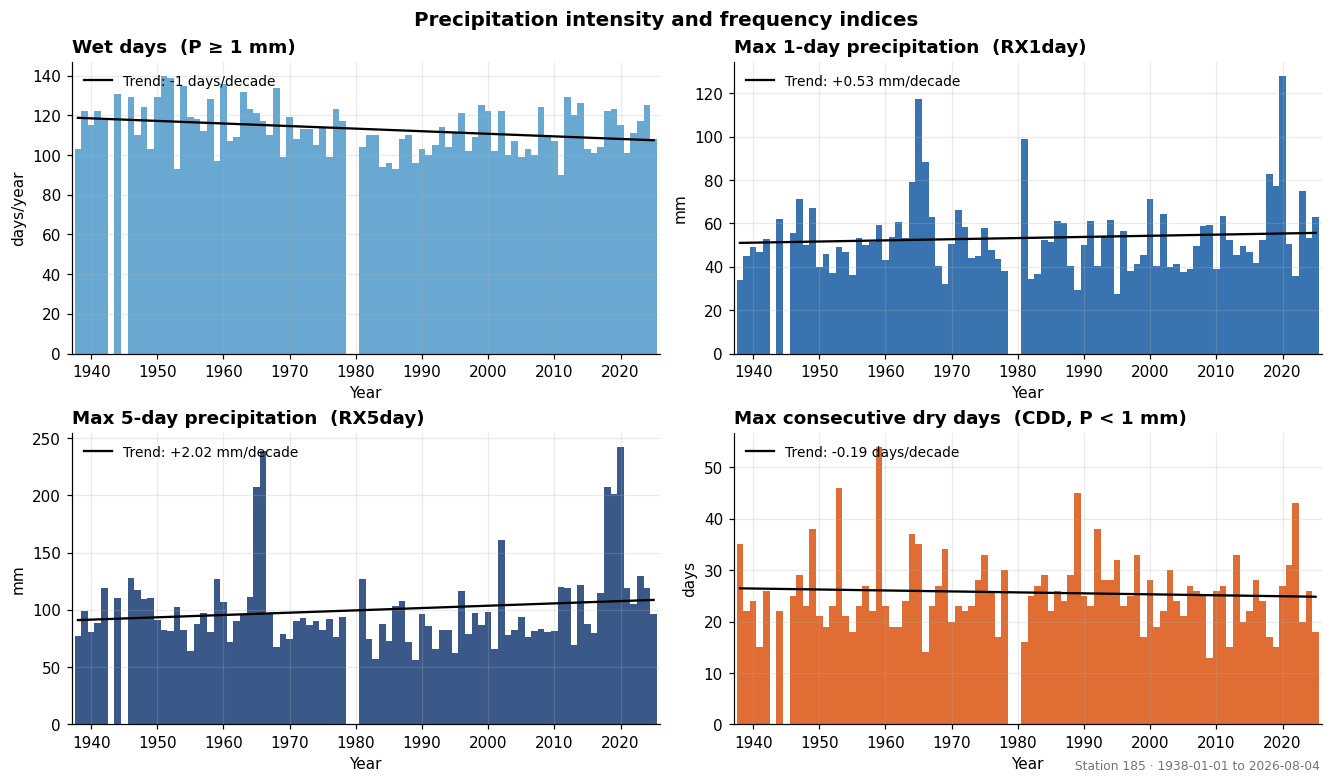

In [ ]:
# @title
def _cdd_per_year(p):
    dry = (p < 1) & p.notna()
    def max_run(vals):
        m = c = 0
        for v in vals:
            if v:
                c += 1
                if c > m:
                    m = c
            else:
                c = 0
        return m
    return dry.groupby(dry.index.year).apply(lambda s: max_run(s.values))


def plot_precipitation_indices(df, save_path=None):
    p = df["Precipitation"]
    yr = p.index.year
    mask = _valid_years_mask(p)

    def _keep_valid(s):
        return s.where(mask.reindex(s.index, fill_value=False)).dropna()

    wet_days = _keep_valid(((p >= 1) & p.notna()).groupby(yr).sum().astype(float))
    rx1      = _keep_valid(p.groupby(yr).max())
    rx5      = _keep_valid(p.rolling(5, min_periods=5).sum().groupby(yr).max())
    cdd      = _keep_valid(_cdd_per_year(p).astype(float))

    panels = [
        ("Wet days  (P ≥ 1 mm)",                       wet_days, "days/year", "days", "#4292c6"),
        ("Max 1-day precipitation  (RX1day)",          rx1,      "mm",        "mm",   "#08519c"),
        ("Max 5-day precipitation  (RX5day)",          rx5,      "mm",        "mm",   "#08306b"),
        ("Max consecutive dry days  (CDD, P < 1 mm)",  cdd,      "days",      "days", "#d94801"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
    axes = axes.flatten()
    for ax, (label, s, ylabel, unit, color) in zip(axes, panels):
        if s.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_yticks([]); continue
        ax.bar(s.index, s.values, color=color, alpha=0.8, width=1.0, edgecolor="none")
        _add_trend(ax, s.index.values, s.values, unit=unit)
        ax.set_title(label, loc="left"); ax.set_ylabel(ylabel); ax.set_xlabel("Year")
        ax.margins(x=0.005)
    fig.suptitle("Precipitation intensity and frequency indices",
                 fontsize=13, fontweight="bold")
    _station_footer(fig, df)
    if save_path:
        fig.savefig(save_path)
plot_precipitation_indices(
    df,
    os.path.join(plot_subdirs["climate_indices"], "precipitation_indices.png"),
)

### **9.3 Growing season length**

Standard phenological proxy: growing season begins on the first spring day
where the **5-day running mean temperature** crosses 5 °C upward, and ends on
the last day after Jul 1 where it stays at/above 5 °C.

Two stacked panels:

- **Top**: GSL bars per year + linear trend (days/decade).
- **Bottom**: spring start and autumn end as day-of-year lines. Both usually
  drift apart in warming climates — earlier springs, later autumns.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

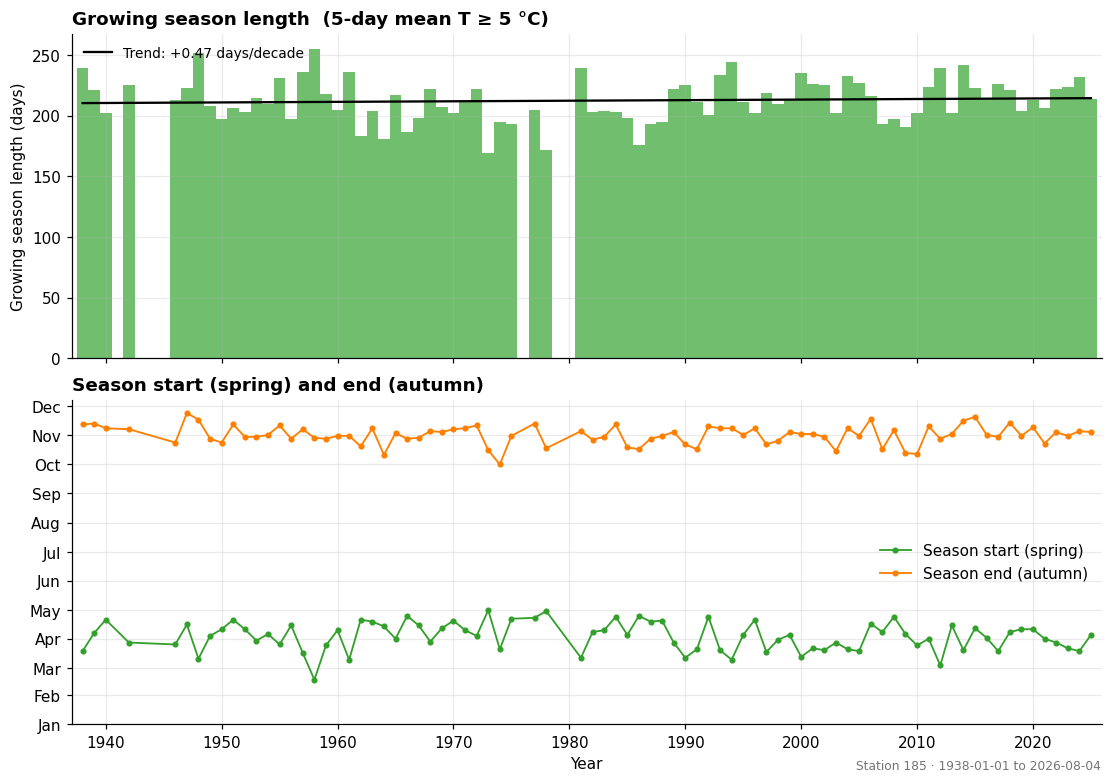

In [ ]:
# @title
def plot_growing_season(df, save_path=None, threshold=5.0):
    t = df["Temperature"]
    rm = t.rolling(5, min_periods=5).mean()

    def per_year(g):
        g = g.dropna()
        if g.empty:
            return pd.Series({"gsl": np.nan, "start": np.nan, "end": np.nan})
        above = g >= threshold
        if not above.any():
            return pd.Series({"gsl": np.nan, "start": np.nan, "end": np.nan})
        first_idx = int(above.values.argmax())
        start = g.index[first_idx].dayofyear
        second_half = above[above.index.month >= 7]
        if not second_half.any():
            return pd.Series({"gsl": np.nan, "start": start, "end": np.nan})
        last = second_half.index[np.where(second_half.values)[0][-1]].dayofyear
        return pd.Series({"gsl": last - start + 1, "start": start, "end": last})

    result = rm.groupby(rm.index.year).apply(per_year)
    if isinstance(result, pd.Series):
        result = result.unstack()
    valid = _valid_years_mask(t)
    result = result[valid.reindex(result.index, fill_value=False)]
    result = result.dropna(subset=["gsl"])
    if result.empty:
        return None

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                    constrained_layout=True)
    ax1.bar(result.index, result["gsl"], color="#4daf4a", alpha=0.8,
            width=1.0, edgecolor="none")
    _add_trend(ax1, result.index.values, result["gsl"].values, unit="days")
    ax1.set_ylabel("Growing season length (days)")
    ax1.set_title(f"Growing season length  (5-day mean T ≥ {threshold:g} °C)",
                  loc="left")
    ax1.margins(x=0.005)

    ax2.plot(result.index, result["start"], color="#33a02c", marker="o",
             markersize=3, linewidth=1.2, label="Season start (spring)")
    ax2.plot(result.index, result["end"], color="#ff7f00", marker="o",
             markersize=3, linewidth=1.2, label="Season end (autumn)")
    month_starts = [pd.Timestamp(2001, m, 1).dayofyear for m in range(1, 13)]
    ax2.set_yticks(month_starts); ax2.set_yticklabels(month_names)
    ax2.set_xlabel("Year")
    ax2.set_title("Season start (spring) and end (autumn)", loc="left")
    ax2.legend(loc="center right"); ax2.margins(x=0.005)

    _station_footer(fig, df)
    if save_path:
        fig.savefig(save_path)
plot_growing_season(df, os.path.join(plot_subdirs["climate_indices"], "growing_season.png"))